In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from scipy import stats
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, GridSearchCV, cross_val_score, cross_validate, learning_curve, validation_curve
from sklearn.datasets import load_breast_cancer, load_diabetes, make_moons, make_classification, load_digits
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, balanced_accuracy_score, roc_curve, roc_auc_score, precision_recall_curve,
                             average_precision_score, ConfusionMatrixDisplay)

RANDOM_STATE=42
rand_num_gen = np.random.default_rng(RANDOM_STATE)

###**train_test_split example**

In [21]:
X,y = load_breast_cancer(return_X_y=True)
col_dataset = load_breast_cancer()
print(f"# of Samples : {X.shape[0]}")
print(f'# of features : {X.shape[1]}')
print(dict(zip(col_dataset.target_names,np.bincount(y))))

X_train,X_val,y_train,y_val = train_test_split(X,y,train_size=0.75,random_state=RANDOM_STATE,stratify=y)
print("\n")
print(f"Train sample : {X_train.shape[0]}",f"Test Sample : {X_val.shape}",sep='\n')
print("\n")
print(f"% of class 1 in train : {y_train.mean()*100}",f"% of class 1 in test : {y_val.mean()*100}")

# of Samples : 569
# of features : 30
{np.str_('malignant'): np.int64(212), np.str_('benign'): np.int64(357)}


Train sample : 426
Test Sample : (143, 30)


% of class 1 in train : 62.676056338028175 % of class 1 in test : 62.93706293706294


In [65]:
X,y = load_breast_cancer(return_X_y=True)
X_train,X_val,y_train,y_val = train_test_split(X,y,train_size=0.75,random_state=RANDOM_STATE,stratify=y)

###**Single Split Train and Validation**


1.   A single train-validation split will always give noisy estimate of model.
2.   We can't assume the split to be an ideal representation of data.
1.   It's just a part or fraction of distribution on which we trained and validated our model!








  

The mean,std. dev., min and max values of accuracy is : 0.977097902097902, 0.011092332439524627, 0.951048951048951. 1.0


(0.95, 1.0)

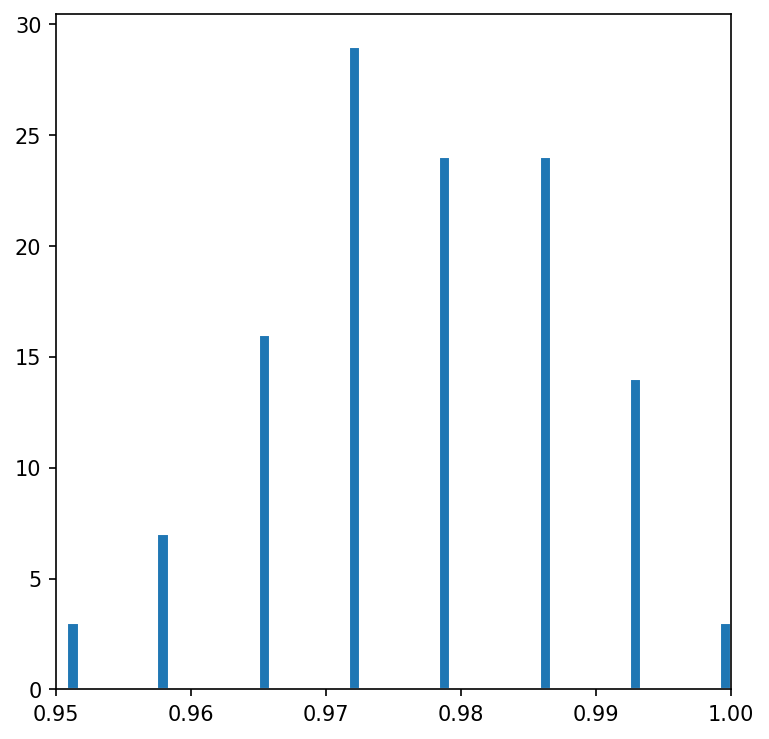

In [22]:

result_score = []
for iter in range(120):
  X_t,X_v,y_t,y_v = train_test_split(X,y,random_state=iter,train_size=0.75,stratify=y)
  model_pipeline = make_pipeline(StandardScaler(),LogisticRegression(max_iter=5000)) # Max number of iterations to opt Logistic Regression model (that's parameters weigths and bias)
  model_pipeline.fit(X_t,y_t)
  result_score += [model_pipeline.score(X_v,y_v)]
result_score = np.array(result_score)

print("The mean,std. dev., min and max values of accuracy is : {}, {}, {}. {}".format(result_score.mean(),result_score.std(),result_score.min(),result_score.max()))
fig = plt.figure(figsize=(5,5),dpi=150)
ax = fig.add_axes([0.1,0.1,0.9,0.9])
ax.hist(result_score,bins=60,edgecolor='white',range=(0.95,1))
ax.set_xlim([0.95,1])

###**K-Fold Cross Validation**


1.   The dataset is split into k parts (known as folds)
2.   In each iteration we give k-1 folds for training and an unique fold for validation.


1.   Hence, we get k scores (which spans/cover over entire dataset).
2.   We find the average, std. dev., min and max value for scores to see whether getting stable estimate of score or not.





In [23]:
## Now we will train and test our model using K-fold

model_new = make_pipeline(StandardScaler(), LogisticRegression(max_iter=20))
k_fold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
k_acc_score = cross_val_score(model_new,X,y,cv=k_fold,scoring='accuracy')

print(f"Accuracy across 5 split of K Fold is {k_acc_score}")
print(f"Accuracy of the model (acc. to K Fold Cross Validation) is : {k_acc_score.mean()} +/- {k_acc_score.std()}")

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy across 5 split of K Fold is [0.97368421 0.98245614 0.96491228 0.99122807 0.97345133]
Accuracy of the model (acc. to K Fold Cross Validation) is : 0.9771464058376029 +/- 0.008964382519164905


###**Stratified K-Fold**


1.   Stratified K-Fold ensures that the proportion of classes in each fold is nearly same (unlike K-Fold)
2.   It's becomes quite important in cases when we are handling severely imbalanced dataset.



In [24]:
x_syn,y_syn = make_classification(n_samples=1000,n_features=20,n_informative=5,n_redundant=2,weights=[0.05,0.95],flip_y=0.01,random_state=RANDOM_STATE)
stats_per_split = []

for name, spl, in [("K Fold (w/o shuffle)",KFold(n_splits=5,shuffle=False)),
                    ("K Fold (w shuffle)",KFold(n_splits=5,shuffle=True,random_state=RANDOM_STATE)),
                    ("Stratified K Fold",StratifiedKFold(n_splits=5,shuffle=True,random_state=RANDOM_STATE))]:
  pro_of_pos_per_fold = np.array([y_syn[idx].mean() for _,idx in spl.split(x_syn,y_syn)])
  stats_per_split.append({'Split_Name':name,**{f"fold {i}" : p for i,p in enumerate(pro_of_pos_per_fold)},'range':pro_of_pos_per_fold.max() - pro_of_pos_per_fold.min()})

split_stats_df = pd.DataFrame(stats_per_split)
print(split_stats_df)

             Split_Name  fold 0  fold 1  fold 2  fold 3  fold 4  range
0  K Fold (w/o shuffle)   0.965   0.940   0.935   0.950   0.950  0.030
1    K Fold (w shuffle)   0.955   0.945   0.950   0.940   0.950  0.015
2     Stratified K Fold   0.950   0.950   0.950   0.945   0.945  0.005


###**leakage bug demonstration**


1.   **Right way :-**

     Split the data (preferably StratifiedKFold)
     
     extract useful feats from 'train split'
     
     train model.



2.   **Wrong way (introduces data leakage into model) :-**
     extract useful feats. observing entire dataset (including val)
     
     split the data
     
     train the model.



In [25]:
rng = np.random.default_rng(0)
n_samples, n_features = 100, 5000
X_noise = rng.normal(size=(n_samples, n_features))
y_noise = rng.integers(0, 2, size=n_samples)   # labels are pure coin flips

# --- WRONG: select features using all the data, then cross-validate -------------
selector = SelectKBest(f_classif, k=20).fit(X_noise, y_noise)   # <-- sees every label
X_selected = selector.transform(X_noise)
wrong = cross_val_score(LogisticRegression(max_iter=5000), X_selected, y_noise,
                        cv=StratifiedKFold(5, shuffle=True, random_state=0)).mean()

# --- RIGHT: selection lives in the pipeline, refit on each training fold --------
pipe_ok = Pipeline([("select", SelectKBest(f_classif, k=20)),
                    ("clf", LogisticRegression(max_iter=5000))])
right = cross_val_score(pipe_ok, X_noise, y_noise,
                        cv=StratifiedKFold(5, shuffle=True, random_state=0)).mean()

print("Labels are random coin flips -- the honest score must be about 0.50\n")
print(f"  Selection BEFORE splitting (leaky) : {wrong:.3f}   <-- inflated score because test samples were used to extract useful features")
print(f"  Selection INSIDE the pipeline      : {right:.3f}   <-- the truth")

Labels are random coin flips -- the honest score must be about 0.50

  Selection BEFORE splitting (leaky) : 0.870   <-- inflated score because test samples were used to extract useful features
  Selection INSIDE the pipeline      : 0.500   <-- the truth


###**Nested Cross Validation**

In [26]:
param_grid = {"clf__C": [0.001, 0.01, 0.1, 1, 10, 100]}
pipe = Pipeline([("scale", StandardScaler()),
                 ("clf", LogisticRegression(max_iter=5000))])

inner_cv = StratifiedKFold(4, shuffle=True, random_state=1)
outer_cv = StratifiedKFold(5, shuffle=True, random_state=2)

grid = GridSearchCV(pipe, param_grid, cv=inner_cv, scoring="accuracy")

# Non-nested: tune and report on the same folds
grid.fit(X, y)
non_nested = grid.best_score_

# Nested: the outer loop never sees the tuning decisions
nested_scores = cross_val_score(grid, X, y, cv=outer_cv, scoring="accuracy")

print(f"Best C found        : {grid.best_params_['clf__C']}")
print(f"Non-nested CV score : {non_nested:.4f}   <-- optimistic as we found hyperparameters using same cv strategy")
print(f"Nested CV score     : {nested_scores.mean():.4f} +/- {nested_scores.std():.4f}")
print(f"Optimism gap        : {non_nested - nested_scores.mean():+.4f}")

Best C found        : 1
Non-nested CV score : 0.9807   <-- optimistic as we found hyperparameters using same cv strategy
Nested CV score     : 0.9754 +/- 0.0116
Optimism gap        : +0.0053


### **Thumb Rules for CV selection strategy**

| Situation | Use |
|-----------|-----|
| Plenty of data (>100k), fast iteration | Single train / validation / test split |
| Small or medium dataset | 5- or 10-fold **stratified** CV |
| Very small dataset | Leave-one-out, or repeated stratified CV |
| Tuning **and** reporting | Nested CV |
| Time series | `TimeSeriesSplit` — never shuffle; the future must not train the past |
| Grouped data (patients, users, sessions) | `GroupKFold` — keep a group entirely on one side |

###**Eager Learner vs Lazy Learner**

| | Eager | Lazy |
|---|-------|------|
| Examples | Logistic regression, decision trees, SVM, neural nets, naive Bayes | k-NN, kernel regression, case-based reasoning |
| Training cost | High | Nearly zero |
| Prediction cost | Low, roughly constant | Grows with training-set size |
| Memory after training | Just the parameters | The entire training set |
| Hypothesis | One global fit | A fresh local fit per query |
| New data arrives | Usually needs a refit | Just append it |
| Interpretability | The model can be inspected | Explanation = "these neighbours" |

###**Fitting and Prediction time for Eager and Lazy Learner**

In [29]:
import time

X_big, y_big = make_classification(n_samples=12000, n_features=30, n_informative=12,
                                   n_classes=2, random_state=RANDOM_STATE)
X_big_tr, X_big_te, y_big_tr, y_big_te = train_test_split(
    X_big, y_big, test_size=0.25, random_state=RANDOM_STATE, stratify=y_big)

models = {
    "k-NN (k=5)  [LAZY]":          KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression [EAGER]": LogisticRegression(max_iter=2000),
    "Decision Tree [EAGER]":       DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest [EAGER]":       RandomForestClassifier(n_estimators=60,
                                                          random_state=RANDOM_STATE, n_jobs=1),
}

rows = []
for name, model in models.items():
    t0 = time.perf_counter(); model.fit(X_big_tr, y_big_tr); fit_t = time.perf_counter() - t0
    t0 = time.perf_counter(); pred = model.predict(X_big_te); pred_t = time.perf_counter() - t0
    rows.append({"model": name, "fit time (s)": fit_t, "predict time (s)": pred_t,
                 "ratio predict/fit": pred_t / max(fit_t, 1e-9),
                 "accuracy": accuracy_score(y_big_te, pred)})

print("Training vs prediction cost (9,000 train / 3,000 test)\n")
fit_pred_time_df = pd.DataFrame(rows).set_index("model")
print(fit_pred_time_df)

Training vs prediction cost (9,000 train / 3,000 test)

                             fit time (s)  predict time (s)  \
model                                                         
k-NN (k=5)  [LAZY]               0.004363          0.735844   
Logistic Regression [EAGER]      0.155830          0.000924   
Decision Tree [EAGER]            1.393681          0.001920   
Random Forest [EAGER]            6.264088          0.039534   

                             ratio predict/fit  accuracy  
model                                                     
k-NN (k=5)  [LAZY]                  168.659286  0.967000  
Logistic Regression [EAGER]           0.005928  0.866667  
Decision Tree [EAGER]                 0.001378  0.877667  
Random Forest [EAGER]                 0.006311  0.966000  


### **Demo of Lazy learner prediction time scaling with training data**

In [ ]:
sizes = [500, 1000, 2000, 4000, 6000, 9000]
knn_pred_times, lr_pred_times = [], []
X_query = X_big_te[:2000]

for n in sizes:
    knn = KNeighborsClassifier(n_neighbors=5).fit(X_big_tr[:n], y_big_tr[:n])
    t0 = time.perf_counter(); knn.predict(X_query)
    knn_pred_times.append(time.perf_counter() - t0)

    lr = LogisticRegression(max_iter=2000).fit(X_big_tr[:n], y_big_tr[:n])
    t0 = time.perf_counter(); lr.predict(X_query)
    lr_pred_times.append(time.perf_counter() - t0)

fig, ax = plt.subplots()
ax.plot(sizes, knn_pred_times, "o-", color="#C44E52", lw=2, label="k-NN (lazy)")
ax.plot(sizes, lr_pred_times, "s-", color="#4C72B0", lw=2, label="Logistic Regression (eager)")
ax.set_xlabel("Number of training samples stored")
ax.set_ylabel("Time to predict 2,000 queries (s)")
ax.set_title("Prediction cost vs. training-set size")
ax.legend()
plt.tight_layout(); plt.show()

print(f"k-NN prediction time grew {knn_pred_times[-1]/knn_pred_times[0]:.1f}x "
      f"as the stored set grew {sizes[-1]/sizes[0]:.0f}x.")
print("Logistic Regression stayed flat -- it only multiplies by a fixed weight vector.")

del knn, lr           # release the stored training sets before the next section
import gc; gc.collect()

### **Confusion Matrix, Accuracy, Precision, Recall**

Every classification metric in common use is a function of four counts. Get the confusion
matrix right and the rest is arithmetic.

|                     | **Predicted Negative** | **Predicted Positive** |
|---------------------|------------------------|------------------------|
| **Actual Negative** | TN (true negative)     | FP (false positive) — *Type I error* |
| **Actual Positive** | FN (false negative) — *Type II error* | TP (true positive) |

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN} \qquad
  \text{Precision} = \frac{TP}{TP + FP} \qquad
  \text{Recall} = \frac{TP}{TP + FN}$$

$$\text{Specificity} = \frac{TN}{TN + FP} \qquad
  F_1 = 2\cdot\frac{\text{Precision}\cdot\text{Recall}}{\text{Precision} + \text{Recall}}$$

In words:

- **Precision** — *of everything I flagged, how much was real?* Punishes false alarms.
- **Recall** (sensitivity, TPR) — *of everything real, how much did I catch?* Punishes misses.
- **Specificity** (TNR) — recall for the negative class.
- **F1** — the harmonic mean of precision and recall. Harmonic, not arithmetic, so it collapses
  if either one is near zero. A model with precision 1.0 and recall 0.01 has $F_1 = 0.02$,
  not 0.5.

**Confusion Matrix and Classification Report Code**

In [41]:
model_2 = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000))
model_2.fit(X_train, y_train)
y_pred_2 = model_2.predict(X_val)

cm = confusion_matrix(y_val, y_pred_2) #confusion_from_scratch(y_te, y_pred_bc)
acc, pre, rec, f1 = accuracy_score(y_val,y_pred_2), precision_score(y_val,y_pred_2), recall_score(y_val,y_pred_2), f1_score(y_val,y_pred_2)
print("\n","Confusion Matrix\n",cm,"\n"*2,sep='')
print(f"accuracy = {acc:.3f}")
print(f"precision = {pre:.3f}")
print(f"recall = {rec:.3f}")
print(f"f1_score = {f1:.3f}")



Confusion Matrix
[[52  1]
 [ 1 89]]


accuracy = 0.986
precision = 0.989
recall = 0.989
f1_score = 0.989


### 3.3 Multiclass: micro, macro and weighted averaging

With more than two classes you compute the metric per class (one-vs-rest) and then average.
*How* you average changes the story completely.

- **micro** — pool all TP/FP/FN across classes, then compute once. Big classes dominate. For
  single-label problems, micro-F1 equals accuracy.
- **macro** — compute per class, then take an unweighted mean. **Every class counts equally**,
  so rare classes can drag the score down. This is usually what you want with imbalance.
- **weighted** — per-class, averaged with weights proportional to class support. Sits between
  the two and hides rare-class failures almost as well as micro does.

A 4-class problem with very unequal class sizes

In [49]:
X_mc, y_mc = make_classification(n_samples=3000, n_features=20, n_informative=10,
                                 n_classes=4, n_clusters_per_class=1,
                                 weights=[0.70, 0.20, 0.07, 0.03],
                                 random_state=RANDOM_STATE)
Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(X_mc, y_mc, test_size=0.3,
                                              random_state=RANDOM_STATE, stratify=y_mc)
print("class counts:", np.bincount(y_mc))

mc_model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000))
mc_model.fit(Xm_tr, ym_tr)
ym_pred = mc_model.predict(Xm_te)

rows = []
for avg in ["micro", "macro", "weighted"]:
    rows.append({"averaging": avg,
                 "precision": precision_score(ym_te, ym_pred, average=avg, zero_division=0),
                 "recall":    recall_score(ym_te, ym_pred, average=avg, zero_division=0),
                 "f1":        f1_score(ym_te, ym_pred, average=avg, zero_division=0)})
multi_class_df_1 = pd.DataFrame(rows).set_index("averaging")
print("Same predictions, three averagings")
print('\n',f"{multi_class_df_1}")
print(f"plain accuracy = {accuracy_score(ym_te, ym_pred):.4f}   "
      f"(equal to micro-F1 for single-label problems)\n")

print(classification_report(ym_te, ym_pred, digits=3, zero_division=0))
# fig, ax = plt.subplots(figsize=(4.8, 4.4))
cm_2 = confusion_matrix(ym_te, ym_pred)
# print(cm_2)
plt.tight_layout(); plt.show()

class counts: [2086  603  216   95]
Same predictions, three averagings

            precision    recall        f1
averaging                               
micro       0.942222  0.942222  0.942222
macro       0.856389  0.762879  0.790394
weighted    0.936911  0.942222  0.937044
plain accuracy = 0.9422   (equal to micro-F1 for single-label problems)

              precision    recall  f1-score   support

           0      0.958     0.979     0.968       626
           1      0.930     0.956     0.943       181
           2      0.871     0.831     0.850        65
           3      0.667     0.286     0.400        28

    accuracy                          0.942       900
   macro avg      0.856     0.763     0.790       900
weighted avg      0.937     0.942     0.937       900



<Figure size 640x480 with 0 Axes>

### **4. Overfitting & Underfitting**

- **Underfitting (high bias)** — the model is too simple to capture the pattern. Training error
  is high; test error is high and close to it.
- **Overfitting (high variance)** — the model memorises the training data, including its noise.
  Training error is very low; test error is much higher.

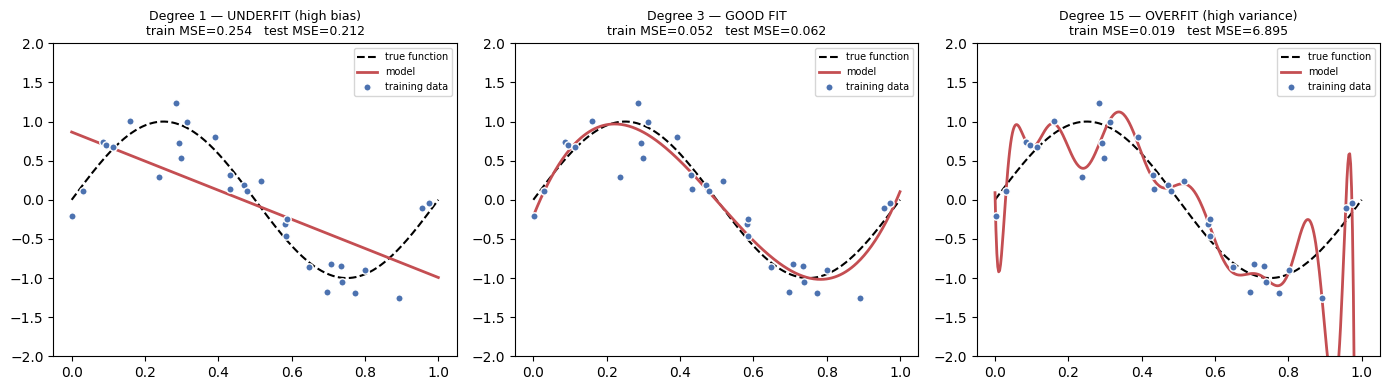

In [53]:
def true_function(x):
    return np.sin(2 * np.pi * x)

rng = np.random.default_rng(3)
n_pts = 30
x_train = np.sort(rng.uniform(0, 1, n_pts))
y_train = true_function(x_train) + rng.normal(0, 0.25, n_pts)
x_plot = np.linspace(0, 1, 400)

x_test_ = np.sort(rng.uniform(0, 1, 200))
y_test_ = true_function(x_test_) + rng.normal(0, 0.25, 200)

degrees = [1, 3, 15]
titles = ["Degree 1 — UNDERFIT (high bias)",
          "Degree 3 — GOOD FIT",
          "Degree 15 — OVERFIT (high variance)"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, d, title in zip(axes, degrees, titles):
    poly = make_pipeline(PolynomialFeatures(d), LinearRegression())
    poly.fit(x_train.reshape(-1, 1), y_train)
    train_mse = np.mean((poly.predict(x_train.reshape(-1, 1)) - y_train) ** 2)
    test_mse  = np.mean((poly.predict(x_test_.reshape(-1, 1)) - y_test_) ** 2)

    ax.plot(x_plot, true_function(x_plot), "k--", lw=1.5, label="true function")
    ax.plot(x_plot, poly.predict(x_plot.reshape(-1, 1)), color="#C44E52", lw=2, label="model")
    ax.scatter(x_train, y_train, s=28, color="#4C72B0", edgecolor="white",
               zorder=5, label="training data")
    ax.set_ylim(-2, 2)
    ax.set_title(f"{title}\ntrain MSE={train_mse:.3f}   test MSE={test_mse:.3f}", fontsize=9)
    ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

### Linear Regression Model with polynomial degree 15 exhibits lowest bias. But does it almost mean it will have lowest variance??

### **Validation curves — sweeping complexity**

Sweep the complexity knob (degree of polynomial) and plot training and validation error together

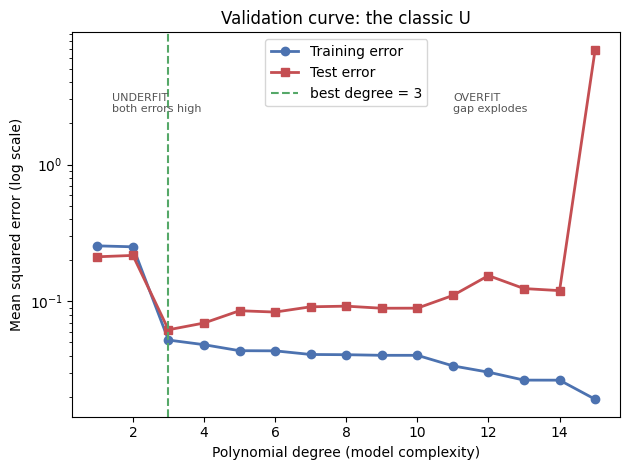

In [54]:
degrees_sweep = range(1, 16)
train_errs, test_errs = [], []
for d in degrees_sweep:
    poly = make_pipeline(PolynomialFeatures(d), LinearRegression())
    poly.fit(x_train.reshape(-1, 1), y_train)
    train_errs.append(np.mean((poly.predict(x_train.reshape(-1, 1)) - y_train) ** 2))
    test_errs.append(np.mean((poly.predict(x_test_.reshape(-1, 1)) - y_test_) ** 2))

best_d = list(degrees_sweep)[int(np.argmin(test_errs))]

fig, ax = plt.subplots()
ax.plot(list(degrees_sweep), train_errs, "o-", color="#4C72B0", lw=2, label="Training error")
ax.plot(list(degrees_sweep), test_errs, "s-", color="#C44E52", lw=2, label="Test error")
ax.axvline(best_d, color="#55A868", ls="--", label=f"best degree = {best_d}")
ax.set_yscale("log")
ax.set_xlabel("Polynomial degree (model complexity)")
ax.set_ylabel("Mean squared error (log scale)")
ax.set_title("Validation curve: the classic U")
ax.legend()
plt.annotate("UNDERFIT\nboth errors high", xy=(1.4, max(test_errs)*0.35), fontsize=8,
             color="#555555")
plt.annotate("OVERFIT\ngap explodes", xy=(11, max(test_errs)*0.35), fontsize=8,
             color="#555555")
plt.tight_layout(); plt.show()

### 4.4 Learning curves — is more data the answer?

A validation curve varies model complexity. A **learning curve** varies the amount of training
data and answers a different, very practical question: *would collecting more data help?*

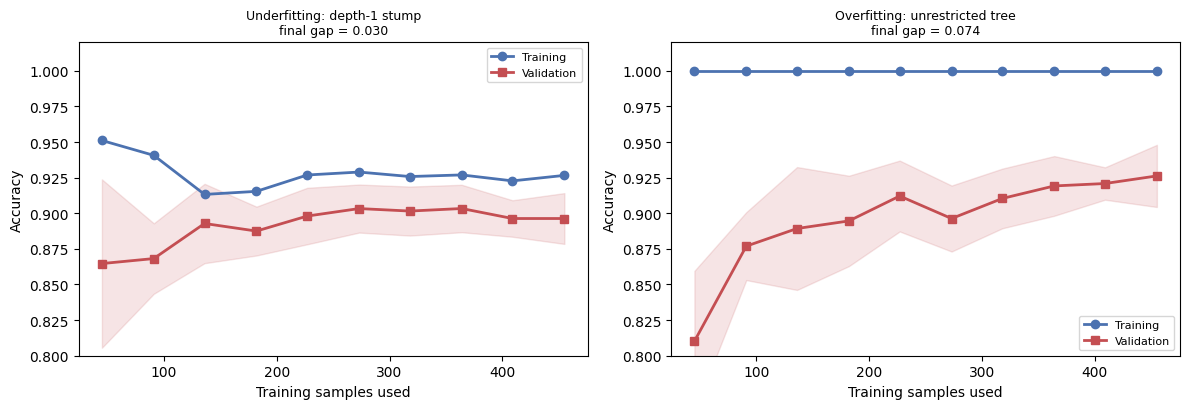

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
setups = [("Underfitting: depth-1 stump", DecisionTreeClassifier(max_depth=1, random_state=0)),
          ("Overfitting: unrestricted tree", DecisionTreeClassifier(random_state=0))]

for ax, (title, est) in zip(axes, setups):
    sizes_abs, tr_sc, va_sc = learning_curve(
        est, X, y, train_sizes=np.linspace(0.1, 1.0, 10),
        cv=StratifiedKFold(5, shuffle=True, random_state=0), scoring="accuracy")
    ax.plot(sizes_abs, tr_sc.mean(axis=1), "o-", color="#4C72B0", lw=2, label="Training")
    ax.plot(sizes_abs, va_sc.mean(axis=1), "s-", color="#C44E52", lw=2, label="Validation")
    ax.fill_between(sizes_abs, va_sc.mean(axis=1)-va_sc.std(axis=1),
                    va_sc.mean(axis=1)+va_sc.std(axis=1), alpha=0.15, color="#C44E52")
    gap = tr_sc.mean(axis=1)[-1] - va_sc.mean(axis=1)[-1]
    ax.set_title(f"{title}\nfinal gap = {gap:.3f}", fontsize=9)
    ax.set_xlabel("Training samples used"); ax.set_ylabel("Accuracy")
    ax.set_ylim(0.80, 1.02); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

On the left the two curves sit almost on top of each other at a mediocre level — a depth-1 stump
cannot express this problem, and no amount of extra data will change that. On the right the
training curve pins at 1.0 while validation lags well below and is still creeping upward at the
right-hand edge — more data would still be buying improvement.

### 4.5 Fixes

| Symptom | Remedies |
|---------|----------|
| **Underfitting** | More expressive model; add/engineer features; reduce regularisation; train longer |
| **Overfitting** | More training data; regularisation (L1/L2, dropout, pruning, `max_depth`); feature selection; early stopping; ensembling/bagging; data augmentation |

# 5. The Bias–Variance Trade-off

Section 4 showed overfitting and underfitting empirically. This section explains *why* the U
shape appears, by decomposing the error into parts you can measure separately.

For squared-error regression, the expected test error at a point $x$ decomposes **exactly**:

$$\mathbb{E}\big[(y - \hat{f}(x))^2\big] \;=\;
\underbrace{\big(\mathbb{E}[\hat{f}(x)] - f(x)\big)^2}_{\textbf{Bias}^2} \;+\;
\underbrace{\mathbb{E}\big[(\hat{f}(x) - \mathbb{E}[\hat{f}(x)])^2\big]}_{\textbf{Variance}} \;+\;
\underbrace{\sigma^2}_{\textbf{Irreducible noise}}$$

The expectation is over **different training sets drawn from the same distribution**. That is
the key idea, and it is why the decomposition feels abstract: in real life you have one training
set. In simulation we can draw hundreds and watch the terms directly.

- **Bias** — how far the *average* model is from the truth. Systematic error from wrong
  assumptions. Simple models have high bias.
- **Variance** — how much the model wobbles when the training set changes. Flexible models have
  high variance.
- **Noise** — the floor. No model can beat it, and if you appear to, you are overfitting.

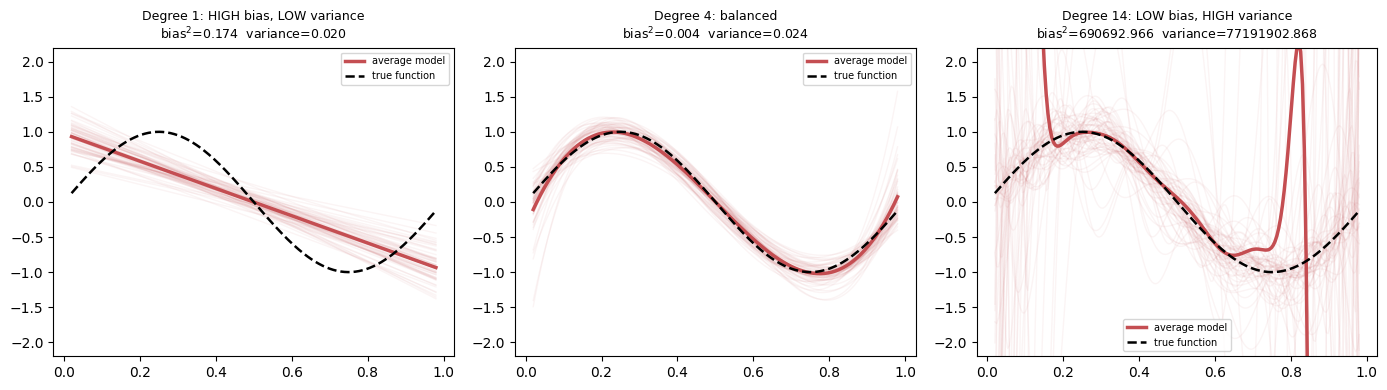

In [56]:
def true_f(x):
    return np.sin(2 * np.pi * x)

NOISE_SIGMA = 0.25
N_TRAIN = 25
x_eval = np.linspace(0.02, 0.98, 200)
f_true_eval = true_f(x_eval)


def sample_dataset(rng, n=N_TRAIN):
    x = rng.uniform(0, 1, n)
    y = true_f(x) + rng.normal(0, NOISE_SIGMA, n)
    return x.reshape(-1, 1), y


def fit_many(degree, n_sets=100, seed=0):
    rng = np.random.default_rng(seed)
    preds = np.empty((n_sets, len(x_eval)))
    for s in range(n_sets):
        xs, ys = sample_dataset(rng)
        m = make_pipeline(PolynomialFeatures(degree), LinearRegression()).fit(xs, ys)
        preds[s] = m.predict(x_eval.reshape(-1, 1))
    return preds


fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, d, label in zip(axes, [1, 4, 14],
                        ["Degree 1: HIGH bias, LOW variance",
                         "Degree 4: balanced",
                         "Degree 14: LOW bias, HIGH variance"]):
    preds = fit_many(d)
    for p in preds[:60]:
        ax.plot(x_eval, p, color="#C44E52", alpha=0.06, lw=1)
    ax.plot(x_eval, preds.mean(axis=0), color="#C44E52", lw=2.5, label="average model")
    ax.plot(x_eval, f_true_eval, "k--", lw=1.8, label="true function")
    bias2 = np.mean((preds.mean(axis=0) - f_true_eval) ** 2)
    var = np.mean(preds.var(axis=0))
    ax.set_title(f"{label}\nbias$^2$={bias2:.3f}  variance={var:.3f}", fontsize=9)
    ax.set_ylim(-2.2, 2.2); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

Observations from above 3 images :-
- **Degree 1** — all 100 fits are nearly the same straight line (tiny variance), but that line
  is nowhere near a sine wave (large bias).
- **Degree 4** — the average model tracks the truth and the individual fits stay reasonably
  close to one another.
- **Degree 14** — the average is roughly right, but individual fits fly off in wild directions,
  especially near the edges. Low bias, enormous variance.

### **5.2 The trade-off curve**

Now sweep the degree and plot all three terms together.

Bias-variance decomposition vs. polynomial degree
              bias^2      variance   noise  total expected error
degree                                                          
1           0.172986  2.352971e-02  0.0625          2.590161e-01
2           0.171772  4.300685e-02  0.0625          2.772787e-01
3           0.003416  1.302095e-02  0.0625          7.893677e-02
4           0.003292  1.806838e-02  0.0625          8.386085e-02
5           0.000143  2.320587e-02  0.0625          8.584861e-02
6           0.000595  7.033233e-02  0.0625          1.334270e-01
7           0.002094  1.543749e-01  0.0625          2.189690e-01
8           0.022976  4.012422e+00  0.0625          4.097897e+00
9           0.472461  7.056502e+01  0.0625          7.109998e+01
10          1.338881  1.989075e+02  0.0625          2.003088e+02
11         30.841582  4.047573e+03  0.0625          4.078477e+03
12        449.227903  8.946682e+04  0.0625          8.991611e+04
13       1343.553185  1.829745e+05  0.06

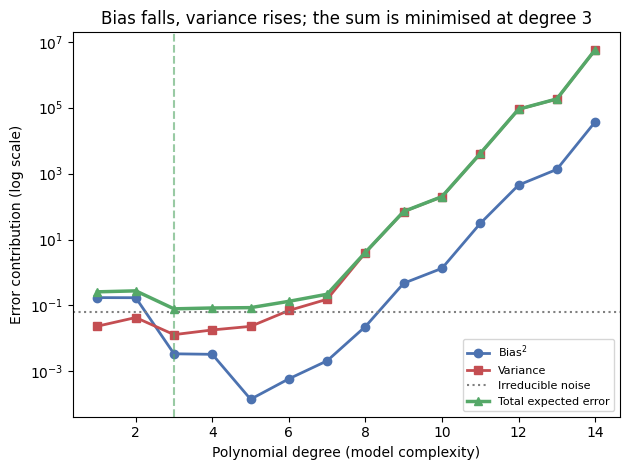

In [58]:
degrees_bv = range(1, 15)
rows = []
for d in degrees_bv:
    preds = fit_many(d, n_sets=150, seed=7)
    mean_pred = preds.mean(axis=0)
    bias2 = np.mean((mean_pred - f_true_eval) ** 2)
    var   = np.mean(preds.var(axis=0))
    rows.append({"degree": d, "bias^2": bias2, "variance": var,
                 "noise": NOISE_SIGMA ** 2,
                 "total expected error": bias2 + var + NOISE_SIGMA ** 2})

print("Bias-variance decomposition vs. polynomial degree")
bv = pd.DataFrame(rows).set_index("degree")
print(bv)

fig, ax = plt.subplots()
ax.plot(bv.index, bv["bias^2"], "o-", color="#4C72B0", lw=2, label="Bias$^2$")
ax.plot(bv.index, bv["variance"], "s-", color="#C44E52", lw=2, label="Variance")
ax.axhline(NOISE_SIGMA ** 2, color="grey", ls=":", lw=1.5, label="Irreducible noise")
ax.plot(bv.index, bv["total expected error"], "^-", color="#55A868", lw=2.5,
        label="Total expected error")
ax.axvline(bv["total expected error"].idxmin(), color="#55A868", ls="--", alpha=0.6)
ax.set_yscale("log")
ax.set_xlabel("Polynomial degree (model complexity)")
ax.set_ylabel("Error contribution (log scale)")
ax.set_title(f"Bias falls, variance rises; the sum is minimised at degree "
             f"{bv['total expected error'].idxmin()}")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# 6. Operating Curves: ROC, AUC, EER, DET

A confusion matrix describes **one** threshold. An operating curve describes **all thresholds
at once**, which lets you compare classifiers without committing to an operating point.

Definitions, all computed from the confusion matrix at a given threshold:

$$\text{TPR (recall, sensitivity)} = \frac{TP}{TP+FN} \qquad
  \text{FPR} = \frac{FP}{FP+TN} \qquad
  \text{FNR} = 1 - \text{TPR}$$

- **ROC curve** — TPR against FPR as the threshold sweeps. Up and to the left is better.
- **AUC** — area under the ROC curve. 1.0 is perfect, 0.5 is a coin flip.
- **EER** — Equal Error Rate: the point where FPR = FNR. A single number widely used in
  biometrics (face, speaker, fingerprint verification). Lower is better.
- **DET curve** — FNR against FPR, both on a normal-deviate (probit) scale. Same information as
  ROC, but the warped axes spread out the low-error region where operating points actually live.


> **AUC is the probability that a randomly chosen positive example is scored above a randomly
> chosen negative example.**

In [60]:
scores_2 = model_2.predict_proba(X_val)[:, 1]
rng = np.random.default_rng(0)
pos_scores = scores_2[y_val == 1]
neg_scores = scores_2[y_val == 0]

n_trials = 100_000
a = rng.choice(pos_scores, n_trials)
b = rng.choice(neg_scores, n_trials)
empirical = np.mean(a > b) + 0.5 * np.mean(a == b)

print(f"Random positive outranks random negative : {empirical:.4f}")
print(f"roc_auc_score                            : {roc_auc_score(y_val, scores_2):.4f}")
print(f"difference                               : {abs(empirical - roc_auc_score(y_val, scores_2)):.4f}")

Random positive outranks random negative : 0.9977
roc_auc_score                            : 0.9977
difference                               : 0.0000


### **ERR Computation**

In [63]:
from scipy.optimize import brentq
from scipy.interpolate import interp1d


def compute_eer(y_true, scores):
    "Equal Error Rate plus the threshold that achieves it, by interpolation."
    fpr, tpr, thr = roc_curve(y_true, scores)
    fnr = 1 - tpr
    # nearest-sample estimate (what most quick implementations do)
    i = int(np.nanargmin(np.abs(fnr - fpr)))
    eer_simple = (fpr[i] + fnr[i]) / 2

    # interpolated estimate: solve fpr(x) - fnr(x) = 0 on the FPR axis
    try:
        eer_interp = brentq(lambda x: 1.0 - x - interp1d(fpr, tpr)(x), 0.0, 1.0)
        thr_interp = float(interp1d(fpr, thr)(eer_interp))
    except Exception:
        eer_interp, thr_interp = eer_simple, thr[i]
    return eer_interp, thr_interp, eer_simple


# A simulated verification system: genuine vs impostor similarity scores
rng = np.random.default_rng(4)
n_gen, n_imp = 3000, 6000
genuine  = rng.normal(1.30, 1.0, n_gen)     # same person
impostor = rng.normal(0.00, 1.0, n_imp)     # different people

y_ver = np.r_[np.ones(n_gen), np.zeros(n_imp)].astype(int)
s_ver = np.r_[genuine, impostor]

eer, eer_thr, eer_simple = compute_eer(y_ver, s_ver)
print(f"EER (interpolated) : {eer:.4f}   at threshold {eer_thr:.4f}")
print(f"EER (nearest point): {eer_simple:.4f}")
print(f"ROC-AUC            : {roc_auc_score(y_ver, s_ver):.4f}")

EER (interpolated) : 0.2618   at threshold 0.6608
EER (nearest point): 0.2621
ROC-AUC            : 0.8173


### ROC and DET

In [66]:
model_zoo = {
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    "Decision Tree (d=3)": DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE),
    "k-NN (k=15)":         make_pipeline(StandardScaler(), KNeighborsClassifier(15)),
}

fitted_scores = {}
summary_rows = []
for name, mdl in model_zoo.items():
    mdl.fit(X_train, y_train)
    s = mdl.predict_proba(X_val)[:, 1]
    fitted_scores[name] = s
    e, e_thr, _ = compute_eer(y_val, s)
    summary_rows.append({"model": name,
                         "AUC": roc_auc_score(y_val, s),
                         "EER": e,
                         "accuracy @0.5": accuracy_score(y_val, (s >= 0.5).astype(int))})

print("Threshold-free comparison")
roc_det_df = pd.DataFrame(summary_rows).set_index("model").sort_values("AUC", ascending=False)
print(roc_det_df)

Threshold-free comparison
                          AUC       EER  accuracy @0.5
model                                                 
Logistic Regression  0.997694  0.018868       0.986014
Random Forest        0.994969  0.055556       0.958042
k-NN (k=15)          0.994969  0.037736       0.958042
Decision Tree (d=3)  0.946331  0.068627       0.944056


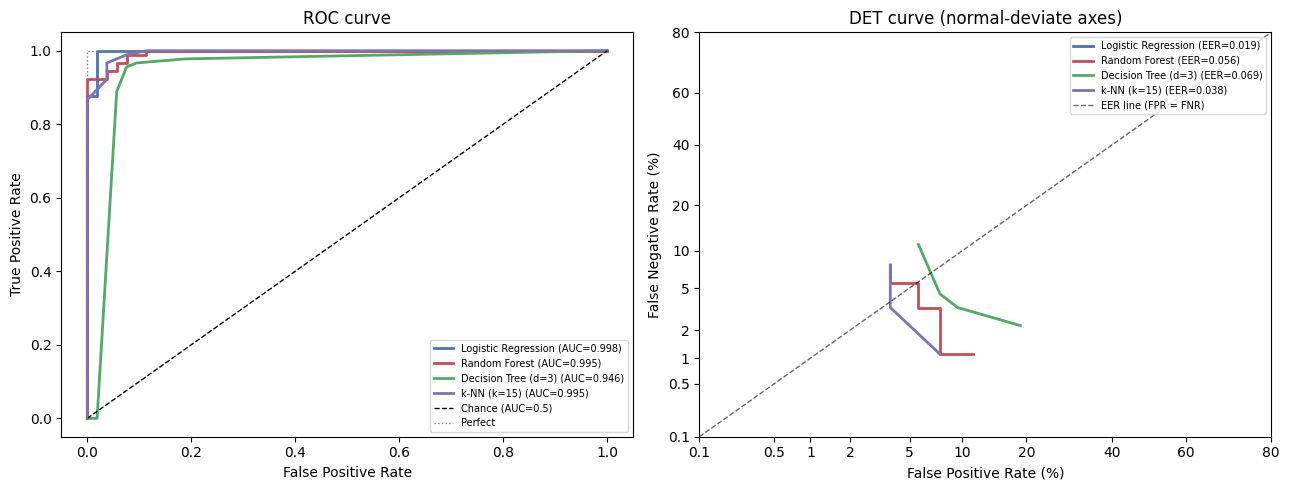

In [70]:
colors = ["#4C72B0", "#C44E52", "#55A868", "#8172B2", "#CCB974"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for (name, s), c in zip(fitted_scores.items(), colors):
    fpr, tpr, _ = roc_curve(y_val, s)
    ax1.plot(fpr, tpr, lw=2, color=c, label=f"{name} (AUC={roc_auc_score(y_val, s):.3f})")
ax1.plot([0, 1], [0, 1], "k--", lw=1, label="Chance (AUC=0.5)")
ax1.plot([0, 0, 1], [0, 1, 1], color="grey", ls=":", lw=1, label="Perfect")
ax1.set_xlabel("False Positive Rate"); ax1.set_ylabel("True Positive Rate")
ax1.set_title("ROC curve"); ax1.legend(fontsize=7, loc="lower right")

ticks = np.array([0.001, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.4, 0.6, 0.8])
for (name, s), c in zip(fitted_scores.items(), colors):
    fpr, tpr, _ = roc_curve(y_val, s)
    fnr = 1 - tpr
    m = (fpr > 0) & (fnr > 0) & (fpr < 1) & (fnr < 1)
    e, _, _ = compute_eer(y_val, s)
    ax2.plot(stats.norm.ppf(fpr[m]), stats.norm.ppf(fnr[m]), lw=2, color=c,
             label=f"{name} (EER={e:.3f})")
lim = stats.norm.ppf([ticks.min(), ticks.max()])
ax2.plot(lim, lim, "k--", lw=1, alpha=0.6, label="EER line (FPR = FNR)")
ax2.set_xticks(stats.norm.ppf(ticks), [f"{t*100:g}" for t in ticks])
ax2.set_yticks(stats.norm.ppf(ticks), [f"{t*100:g}" for t in ticks])
ax2.set_xlim(lim); ax2.set_ylim(lim)
ax2.set_xlabel("False Positive Rate (%)"); ax2.set_ylabel("False Negative Rate (%)")
ax2.set_title("DET curve (normal-deviate axes)")
ax2.legend(fontsize=7, loc="upper right")

plt.tight_layout(); plt.show()

### 7.1 Failure #1 — the accuracy paradox

Here is a classifier that requires no machine learning at all: **always predict "not fraud."**

In [71]:
X_fraud, y_fraud = make_classification(
    n_samples=25000, n_features=25, n_informative=12, n_redundant=4,
    n_clusters_per_class=3, weights=[0.99, 0.01], flip_y=0.001,
    class_sep=1.7, random_state=RANDOM_STATE)

Xf_tr, Xf_te, yf_tr, yf_te = train_test_split(
    X_fraud, y_fraud, test_size=0.3, random_state=RANDOM_STATE, stratify=y_fraud)

print("Simulated fraud-detection dataset")
print(f"  total samples   : {len(y_fraud):,}")
print(f"  negatives (ok)  : {(y_fraud == 0).sum():,}  ({(y_fraud == 0).mean():.2%})")
print(f"  positives (fraud): {(y_fraud == 1).sum():,}  ({(y_fraud == 1).mean():.2%})")
print(f"  imbalance ratio : {(y_fraud == 0).sum() / (y_fraud == 1).sum():.0f} : 1")
print(f"\n  test set: {len(yf_te):,} samples, {yf_te.sum():,} of them fraud")

Simulated fraud-detection dataset
  total samples   : 25,000
  negatives (ok)  : 24,741  (98.96%)
  positives (fraud): 259  (1.04%)
  imbalance ratio : 96 : 1

  test set: 7,500 samples, 78 of them fraud


In [76]:
dummy = DummyClassifier(strategy="most_frequent").fit(Xf_tr, yf_tr)
y_dummy = dummy.predict(Xf_te)

real = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
real.fit(Xf_tr, yf_tr)
y_real = real.predict(Xf_te)
s_real = real.predict_proba(Xf_te)[:, 1]

print(f"'Always predict not-fraud' accuracy : {accuracy_score(yf_te, y_dummy):.4f}")
print(f"Logistic regression accuracy        : {accuracy_score(yf_te, y_real):.4f}")
print(f"Difference                          : {accuracy_score(yf_te, y_real) - accuracy_score(yf_te, y_dummy):+.4f}\n")

TPd, TNd, FPd, FNd = confusion_from_scratch(yf_te, y_dummy)
print(f"The dummy caught {TPd} of the {yf_te.sum()} frauds in the test set.")
print("It is 99% accurate and completely worthless.")

'Always predict not-fraud' accuracy : 0.9896
Logistic regression accuracy        : 0.9899
Difference                          : +0.0003

The dummy caught 0 of the 78 frauds in the test set.
It is 99% accurate and completely worthless.
